In [1]:
import os
import sys
import platform

sys.path.append(os.path.dirname(os.getcwd()))
from benchmark_utils.sync_utils import plotFramesShiftToSyncrhonizeAllSubjectsOneActivity,getMainJointFromMotAndMainBonesFromCSV, getSamplesToSynchronize, SynchronizeAndCutSignals
from benchmark_utils.compare_utils import *
import benchmark_utils.file_utils as fileutil 
import benchmark_utils.plot_utils as plotutil
import benchmark_utils.signal_utils as signalutil

In [2]:

if platform.system() == "Linux":
    dataset_path = '/mnt/d/vidimu_pipeline/VIDIMU'
elif platform.system() == "Darwin":
    dataset_path = '/Volumes/Aux/vidimu_pipeline/VIDIMU'

in_path_bodytrack = os.path.join(dataset_path,'benchmark','dataset_bodytrack')
in_path_motionbert = os.path.join(dataset_path,'benchmark','dataset_motionbert')
in_path_mmpose = os.path.join(dataset_path,'benchmark','dataset_mmpose')
in_path_motionagformer = os.path.join(dataset_path,'benchmark','dataset_motionagformer')
in_path_imus = os.path.join(dataset_path,'benchmark','dataset_imus')
out_path = os.path.join(dataset_path,'benchmark','comparison')
if not os.path.exists(out_path):
    os.makedirs(out_path)

lower_activities = ["A01","A02","A03","A04"]
upper_activities = ["A05","A06","A07","A08","A09","A10","A11","A12","A13"]
dataset_activities = lower_activities + upper_activities
activities_legend = ["walk_forward", "walk_backward", "walk_along","sit_to_stand",
"move_right_arm","move_left_arm","drink_right_arm","drink_left_arm", "assemble_both_arms","throw_both_arms",
"reachup_right_arm","reachup_left_arm","tear_both_arms"]
selected_subjects = ["S40","S41","S42","S44","S46","S47","S48","S49","S50",
            "S51","S52","S53","S54","S55","S56","S57"]


RMSE_SAMPLES = 180
FINAL_LENGTH= 180 
MAX_SYNC_OVERLAP = 15

rmse_lists = []
index_activity = 0

csvlog='infoToSync.csv'
csvlogfile = os.path.join(out_path,csvlog)
if os.path.exists(csvlogfile):
    os.remove(csvlogfile)


# SELECCIONO ESTAS ACTIVIDADES PARA LOS TEST
# selected_subjects = ["S40","S41","S42","S44","S46","S47","S48","S49",
#                      "S50","S51","S52","S53","S54","S55","S56","S57"]
# activity = "A01"          
# activity_legend = "walk_forward" 

## Comparación de modelos

In [3]:
# for activity,legend in zip(dataset_activities,activities_legend):
#     print("Activity: "+activity)
#     rmse_list = compareAllSubjectsOneActivity(csvlog,in_path_bodytrack, in_path_motionbert, in_path_mmpose, in_path_motionagformer, in_path_imus, out_path,selected_subjects,activity,legend,activity+"_("+legend+")_synchronize",RMSE_SAMPLES=RMSE_SAMPLES,MAX_SYNC_OVERLAP=MAX_SYNC_OVERLAP,FINAL_LENGTH=FINAL_LENGTH)


## Métricas de evaluación

In [ ]:
import benchmark_utils.evaluation_utils as evaluation_utils

out_path = os.path.join(dataset_path,'benchmark','evaluation')


In [ ]:

# for act, legend in zip(dataset_activities, activities_legend):
#     print(f"Processing Activity {act}: {legend}")
#     metrics_results = evaluation_utils.calculateAndPlotAllMetrics(
#         csv_bodytrack_path=in_path_bodytrack,
#         csv_motionbert_path=in_path_motionbert,
#         csv_mmpose_path=in_path_mmpose,
#         csv_motionagformer_path=in_path_motionagformer,
#         imu_inpath=in_path_imus,
#         subjects=selected_subjects,
#         activity=act,
#         activity_legend=legend,
#         RMSE_SAMPLES=RMSE_SAMPLES,
#         MAX_SYNC_OVERLAP=MAX_SYNC_OVERLAP,
#         FINAL_LENGTH=FINAL_LENGTH,
#         out_path=out_path,
#         filename_prefix=f"Metrics_{act}"
#     )
    
#     summary_df = evaluation_utils.createSummaryTable(metrics_results)
#     print("Aggregated Performance Summary for Activity", act)
#     print(summary_df)
#     evaluation_utils.plotSummaryTable(summary_df, title=f"Aggregated Performance Metrics for Activity {act}: {legend}",
#                                   out_path=out_path, filename_prefix=f"Summary_{act}")


Processing activity A01: walk_forward


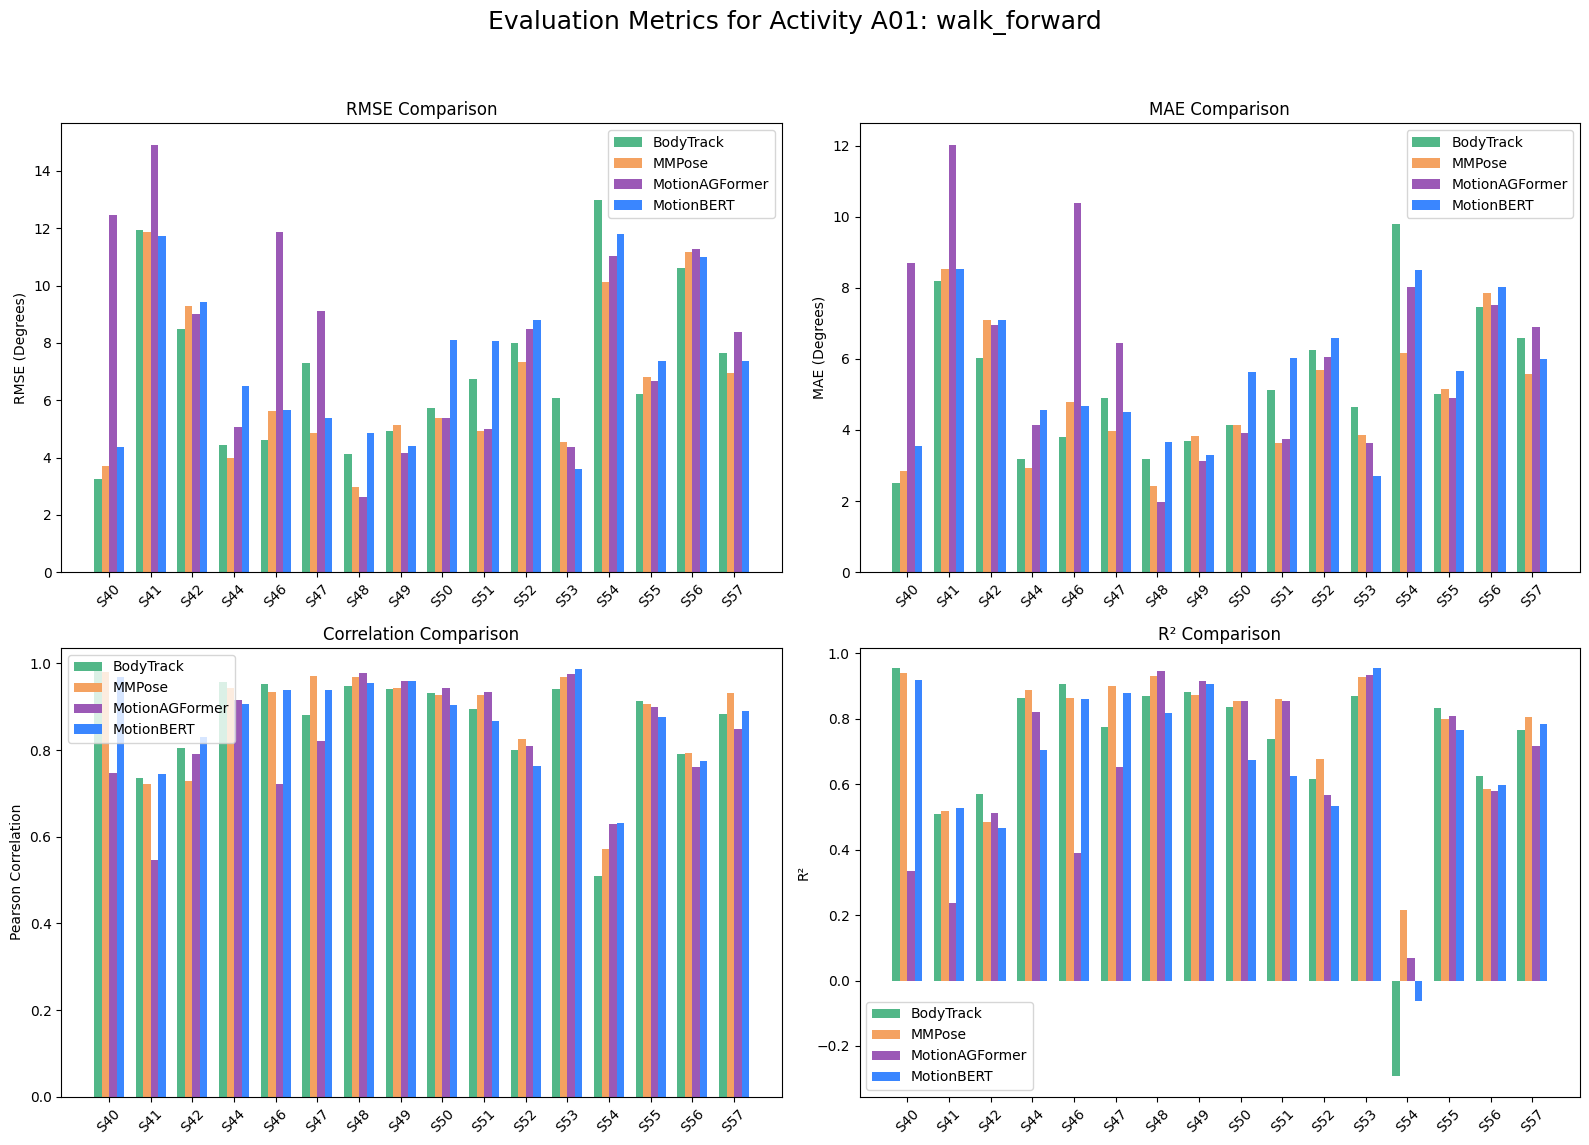

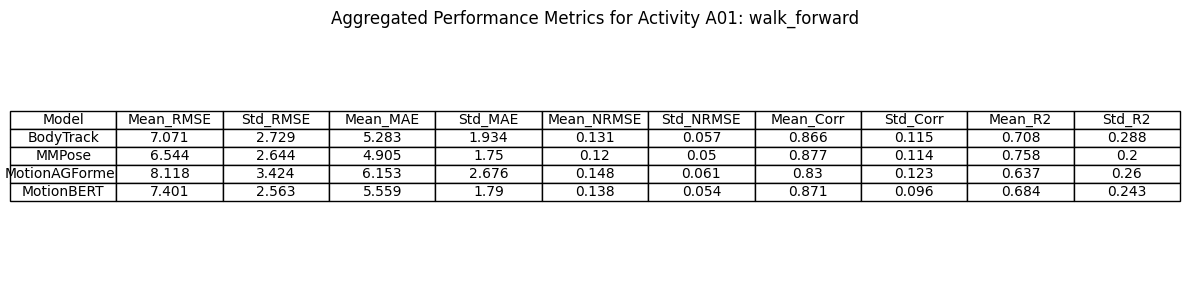

Processing activity A02: walk_backward


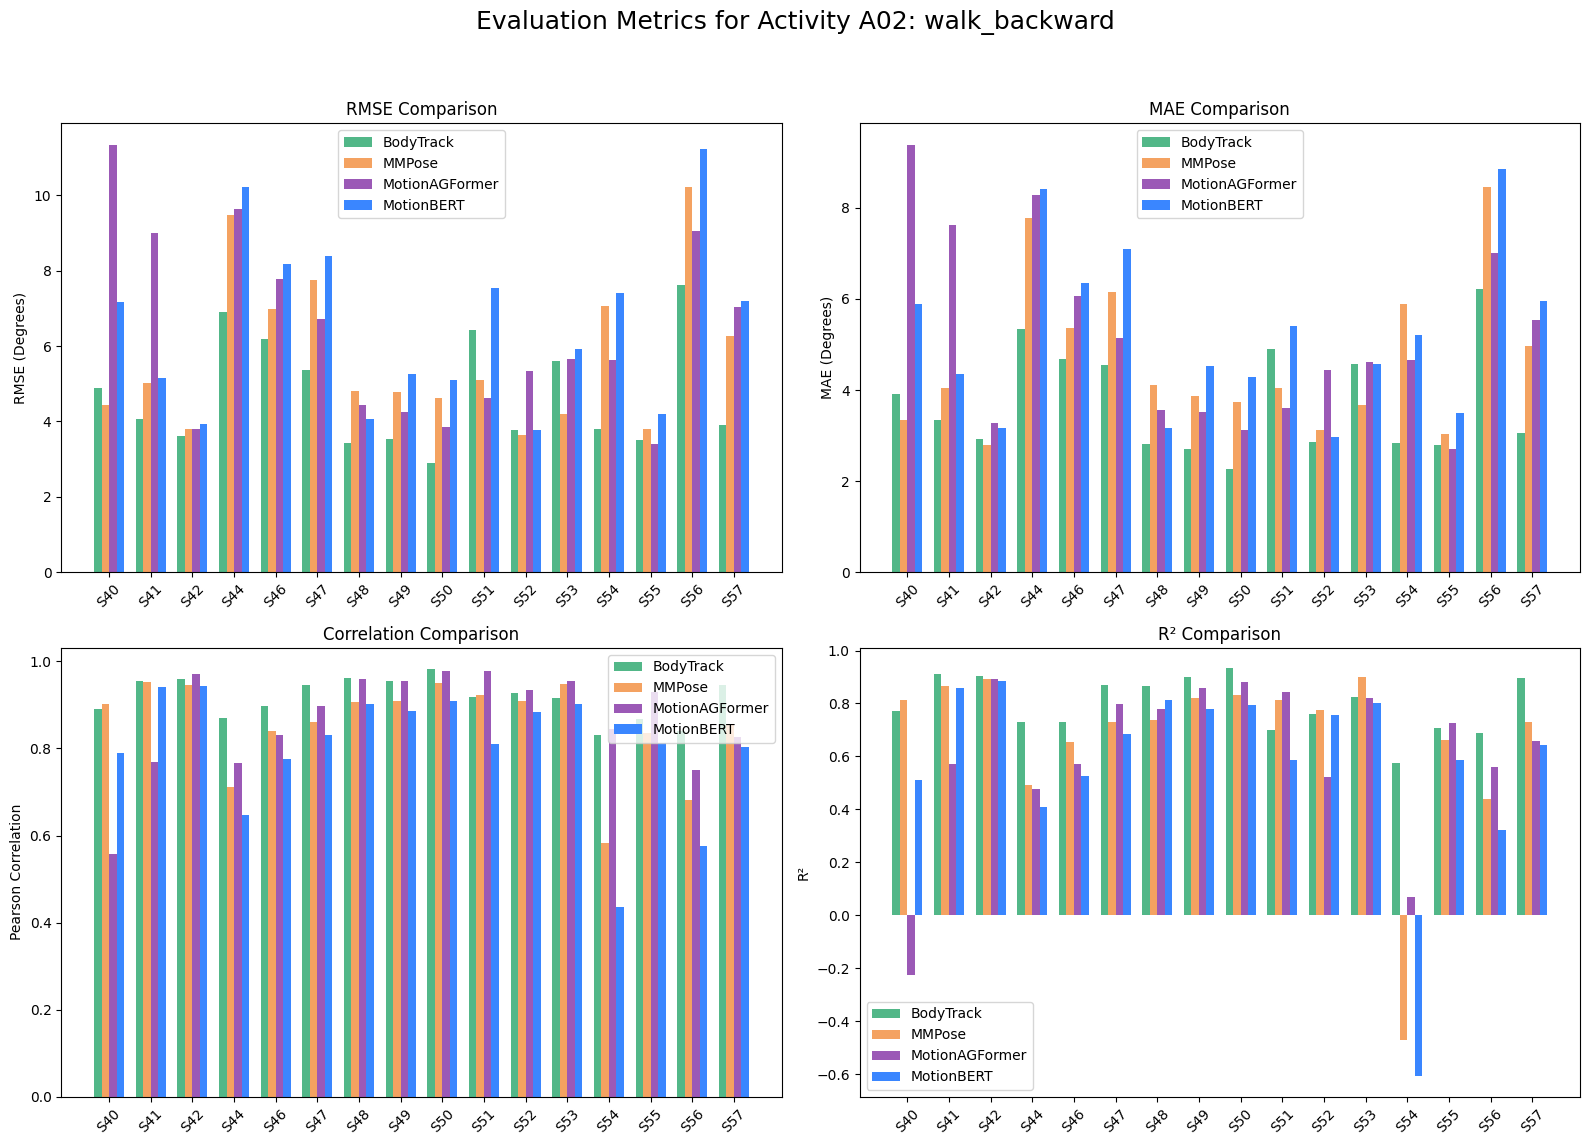

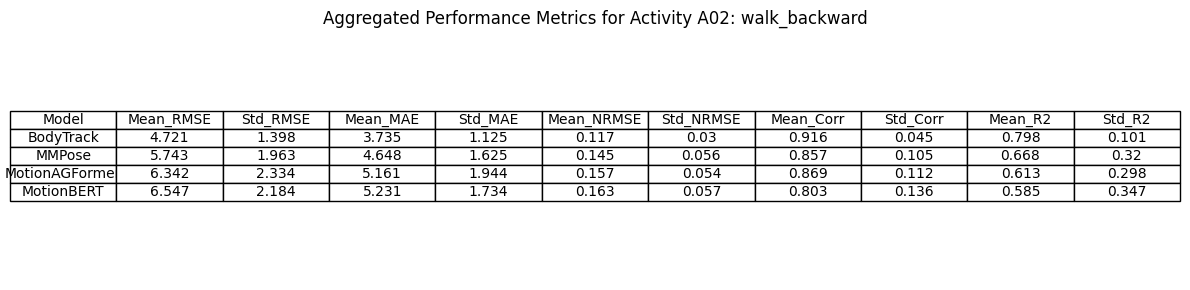

Processing activity A03: walk_along
Data not found for subject S41 for activity A03


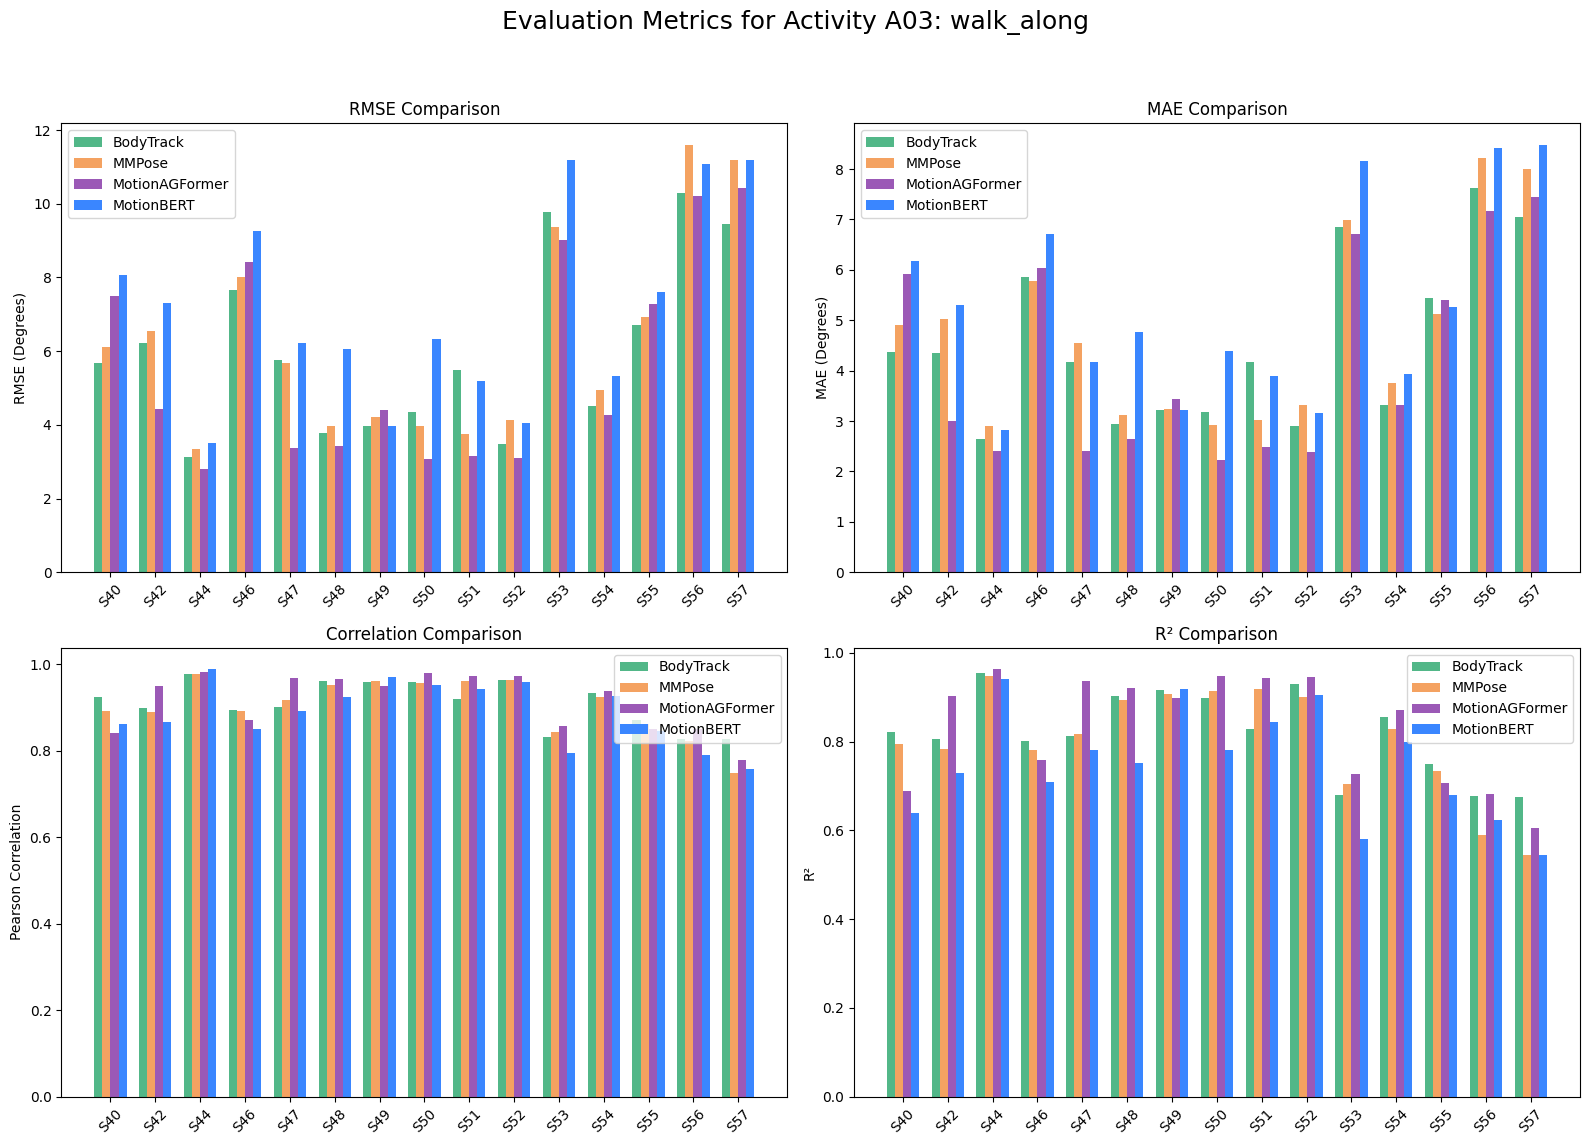

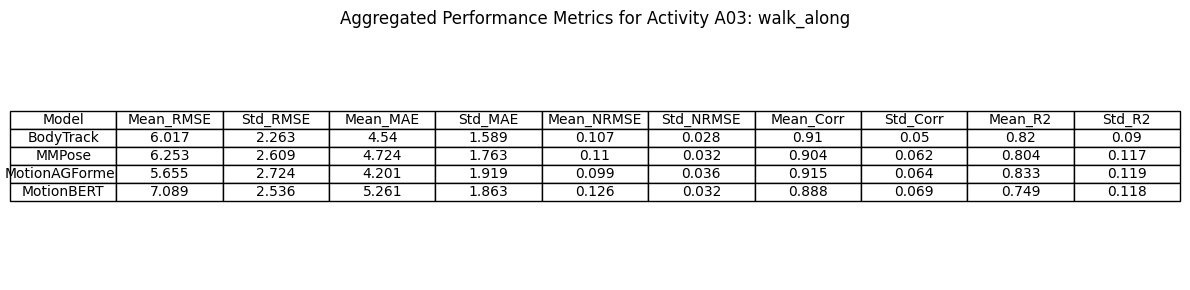

Processing activity A04: sit_to_stand
Data not found for subject S57 for activity A04


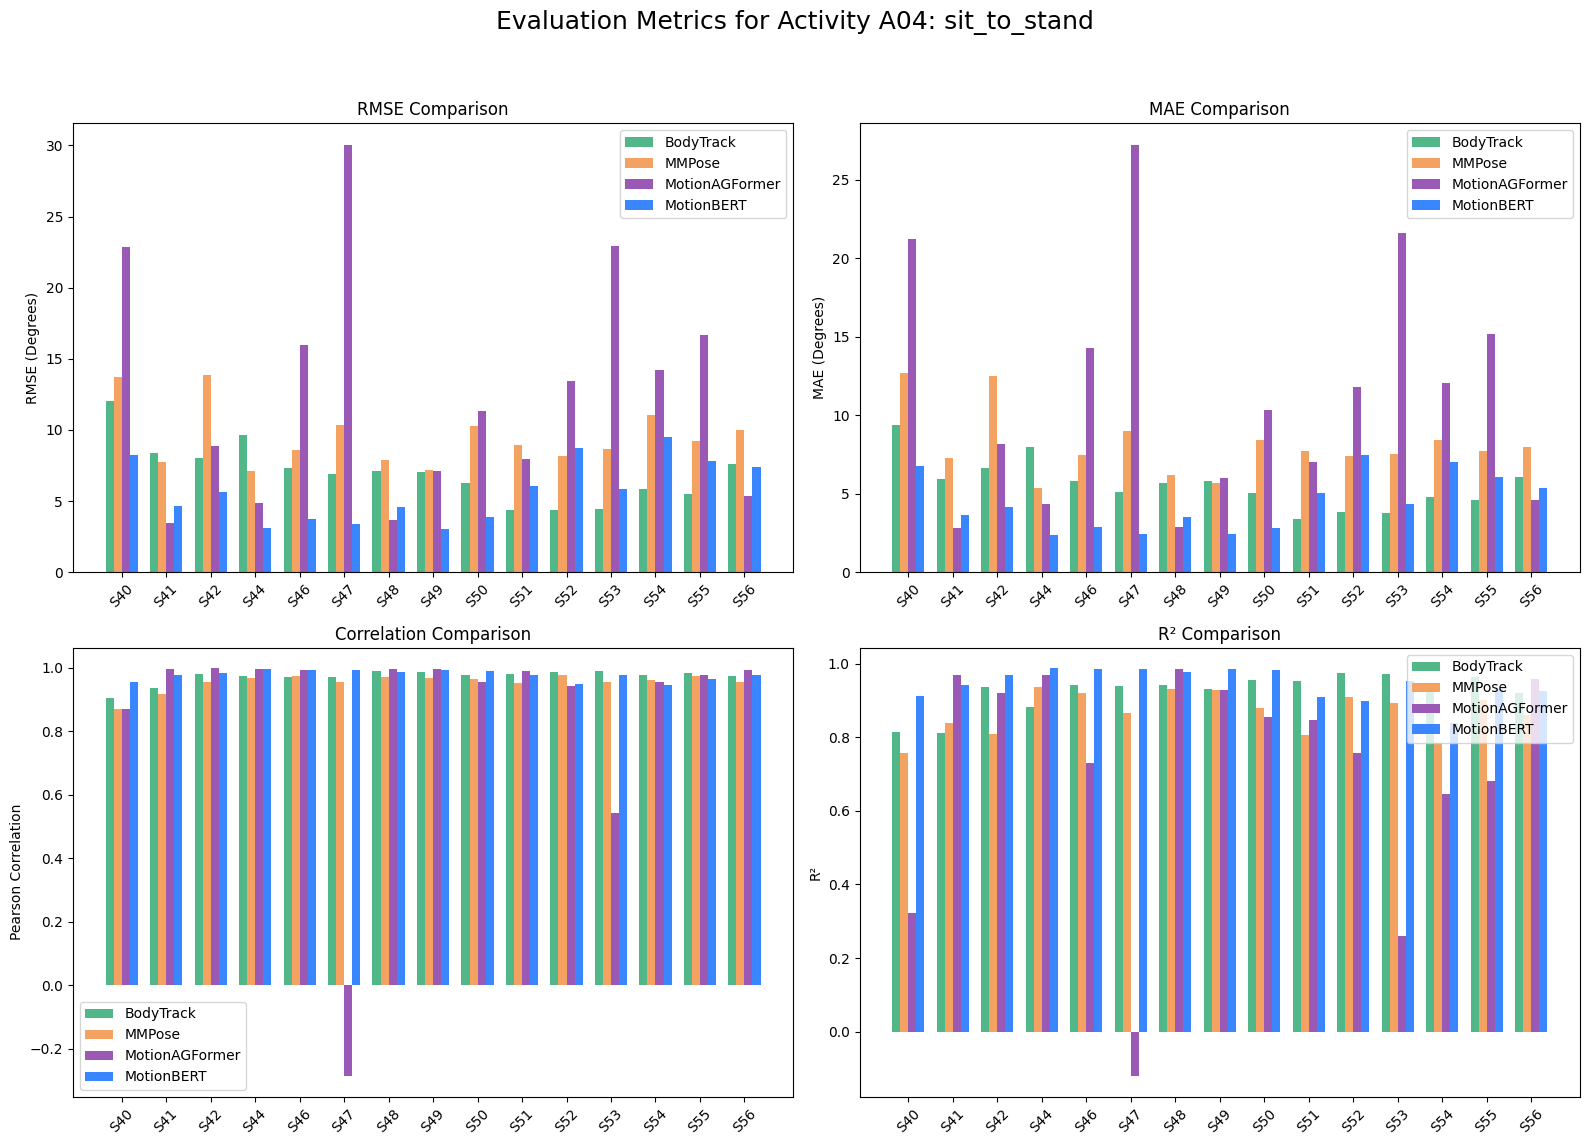

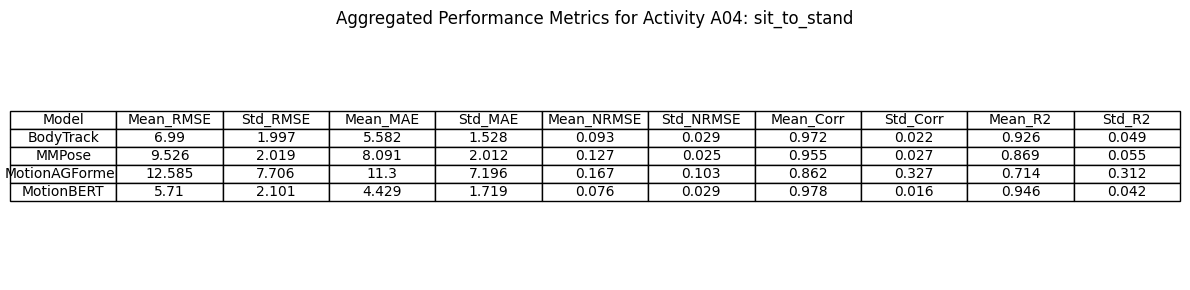

Processing activity A05: move_right_arm


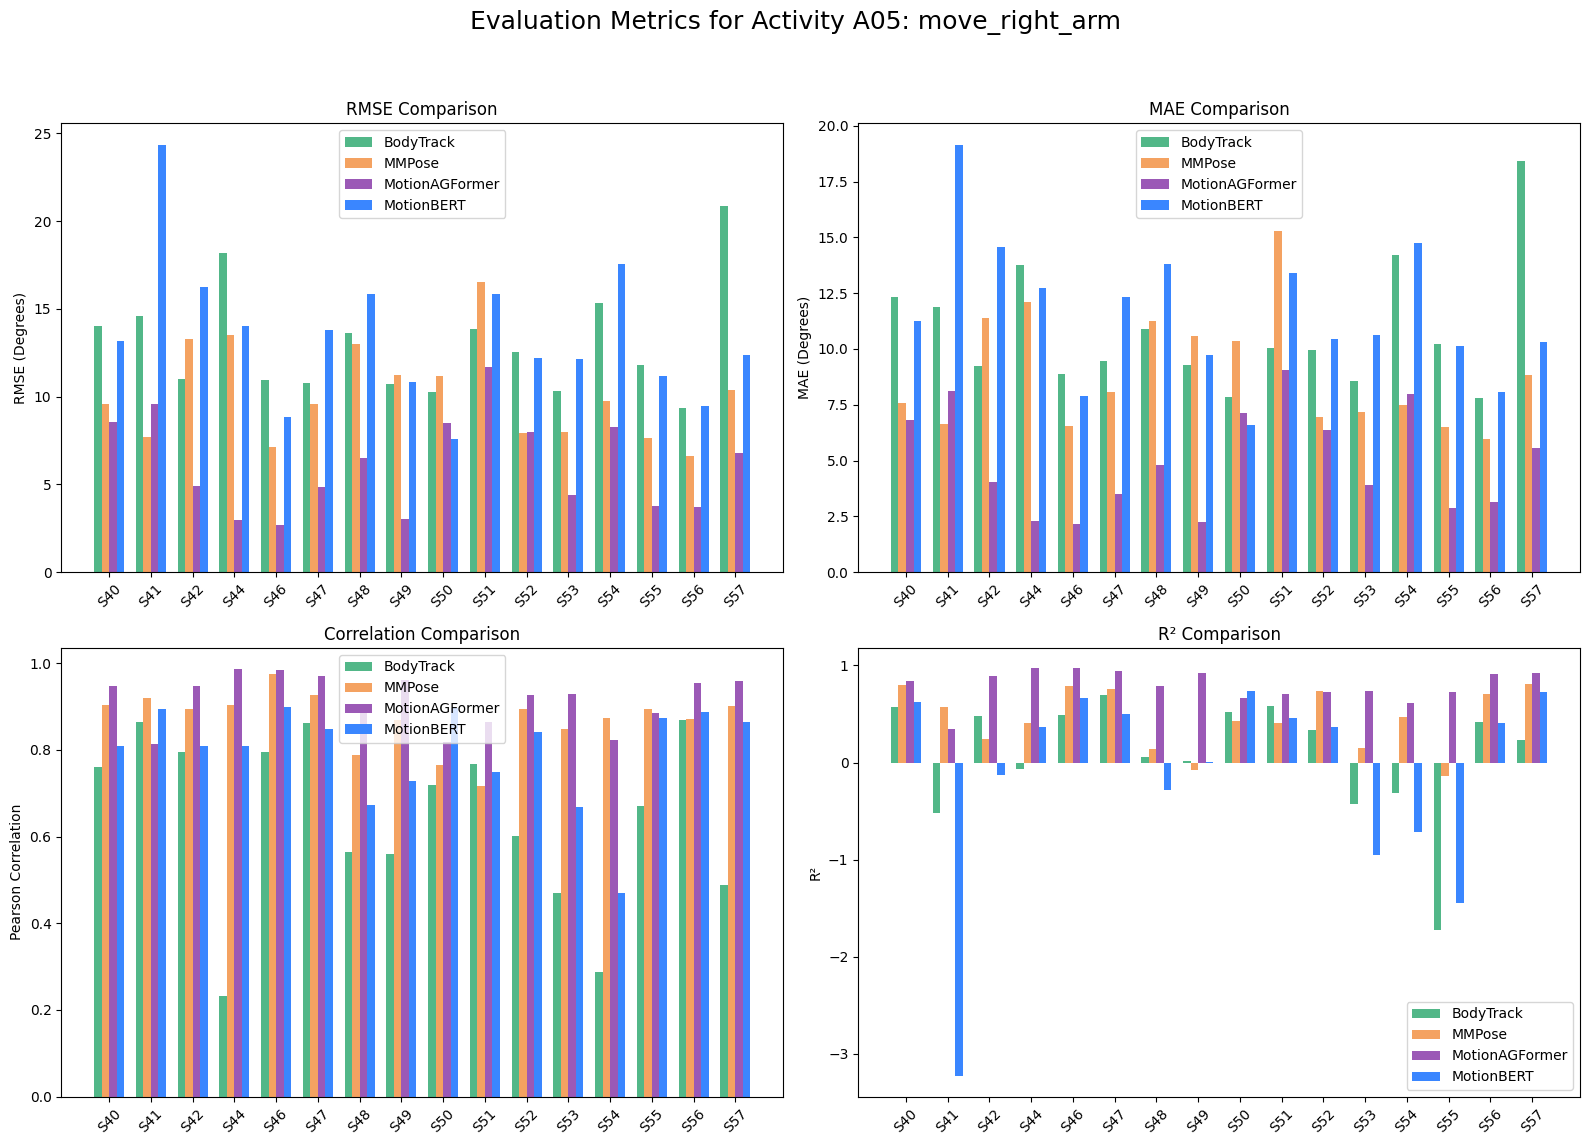

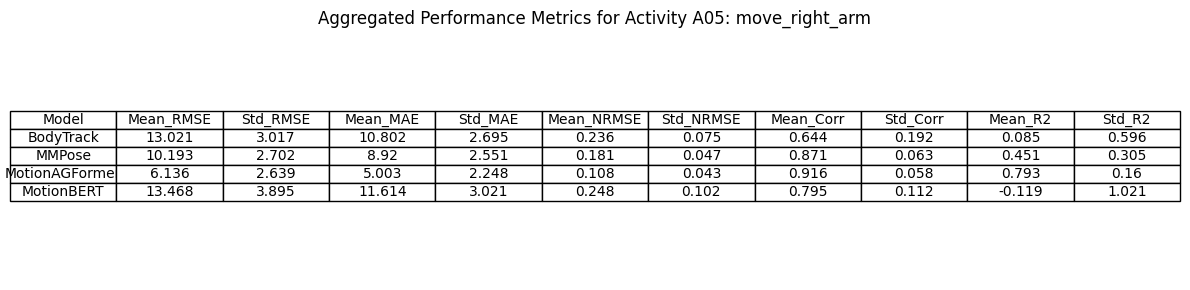

Processing activity A06: move_left_arm


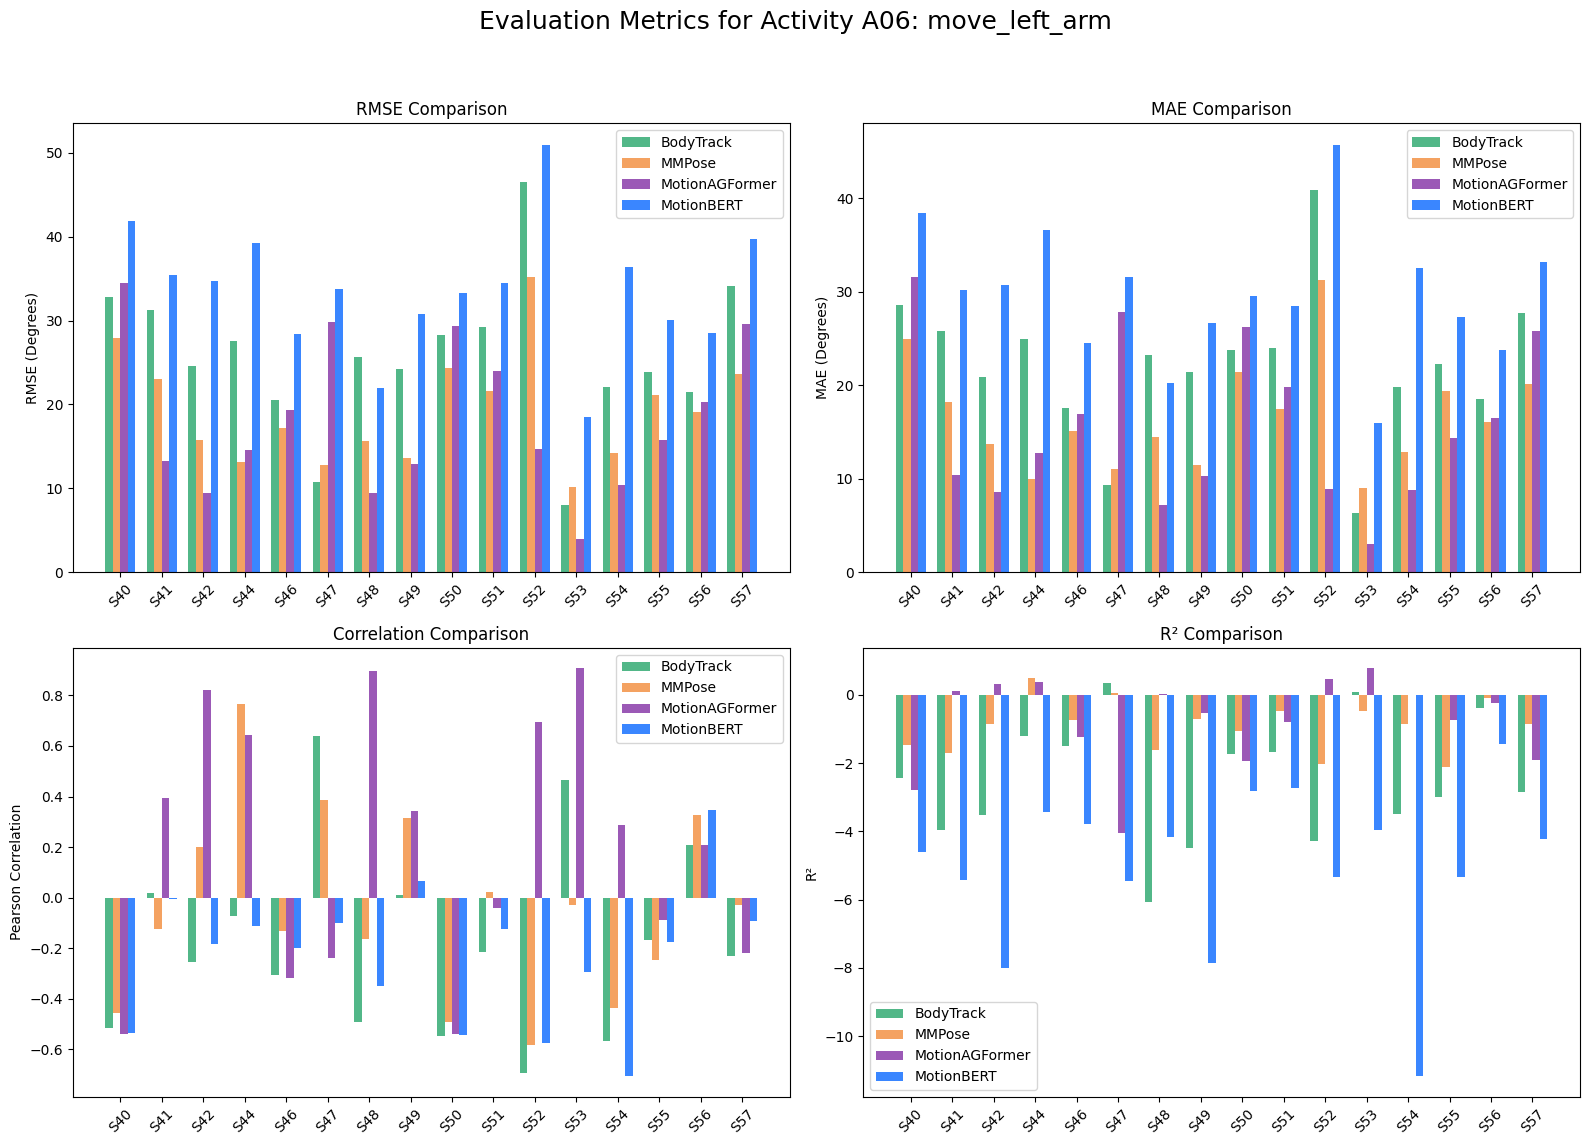

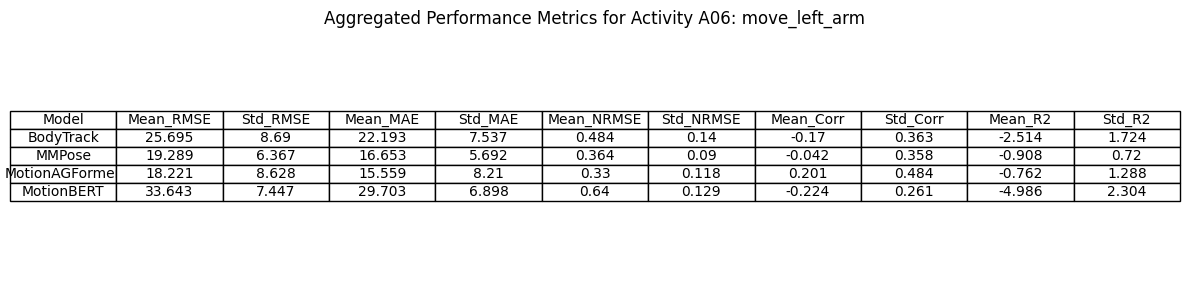

Processing activity A07: drink_right_arm


ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [5]:

# ------------------------------------------------------------------
# (2) Aggregate metrics across all activities and plot the overall benchmarking results.
# ------------------------------------------------------------------
overall_summary, per_activity_summaries = evaluation_utils.benchmarkAllActivities(
    csv_bodytrack_path=in_path_bodytrack,
    csv_motionbert_path=in_path_motionbert,
    csv_mmpose_path=in_path_mmpose,
    csv_motionagformer_path=in_path_motionagformer,
    imu_inpath=in_path_imus,
    subjects=selected_subjects,
    activities=dataset_activities,
    activities_legend=activities_legend,
    RMSE_SAMPLES=RMSE_SAMPLES,
    MAX_SYNC_OVERLAP=MAX_SYNC_OVERLAP,
    FINAL_LENGTH=FINAL_LENGTH,
    out_path=out_path,
    filename_prefix=""
)

print("Overall Aggregated Performance Summary:")
print(overall_summary)